# Fashion Recommendation System using CNN

## 1. Introduction

This project aims to build a CNN-based fashion recommendation system using clothing product images and metadata.

The recommendation system identifies visually similar fashion products by extracting image features through deep learning techniques.

## 2. Importing Libraries

Several Python libraries are imported for data analysis, visualization, and image processing.

- pandas and numpy are used for data manipulation,
- matplotlib and seaborn are used for visualization,
- PIL is used for image handling.

In [1]:
# Fashion Recommendation System using CNN
# 1 Import Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 3. Loading the Dataset

The fashion dataset is loaded using pandas.

The dataset contains product-related information such as gender, category, article type, colour, season, and product names.

In [2]:

# 2 Load Dataset

csv_path = r"C:\Study\Artificial Intelligence\Rocommendation Algorithm\styles.csv"

df = pd.read_csv(csv_path, on_bad_lines='skip')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## 4. Dataset Inspection

The dataset structure is examined by displaying:

- sample observations,
- dataset dimensions,
- column names,
- missing values.

This helps understand the dataset before image preprocessing and CNN modeling.

In [3]:
# 3 - Dataset Inspection
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Dataset Shape:
(44424, 10)

Column Names:
Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseCol

## 5. Image Folder Verification

The image directory is checked to ensure that product images are available.

Each image corresponds to a product ID in the dataset. These images will later be processed by the CNN model for feature extraction.

#  5 - Display Sample Images
sample_ids = df['id'].head(5)

plt.figure(figsize=(15,5))

for i, img_id in enumerate(sample_ids):

    img_file = os.path.join(image_path, f"{img_id}.jpg")

    if os.path.exists(img_file):

        img = Image.open(img_file)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(str(img_id))
        plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Gender Distribution

The distribution of products across gender categories is visualized.

This analysis helps understand whether the dataset is balanced across male, female, and unisex fashion products.

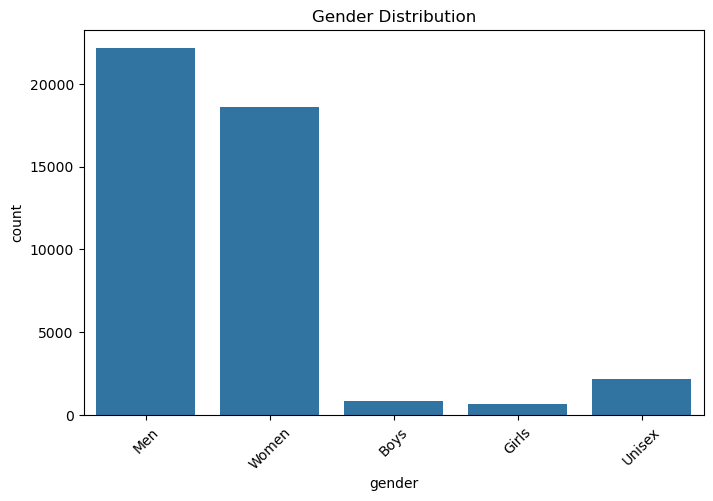

In [4]:
# 4 - Gender Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='gender')

plt.title("Gender Distribution")
plt.xticks(rotation=45)

plt.show()

## 6. Master Category Distribution

The distribution of master product categories is examined.

The dataset mainly contains fashion-related categories such as apparel, accessories, footwear, and personal care products.

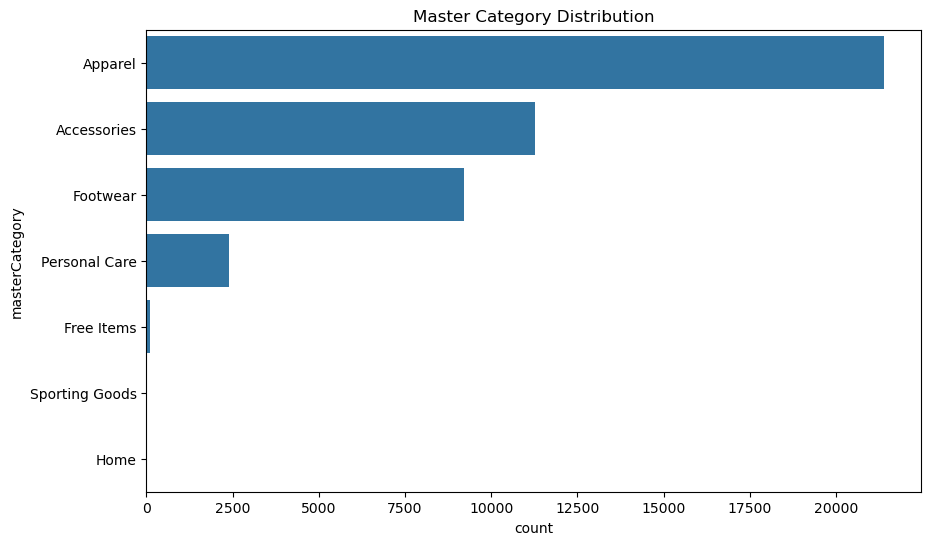

In [5]:
# Master Category Distribution

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='masterCategory',
    order=df['masterCategory'].value_counts().index
)

plt.title("Master Category Distribution")

plt.show()

## 7. Top Article Types

The most common article types are visualized.

This helps identify the dominant product types within the fashion dataset, such as t-shirts, shirts, shoes, or watches.

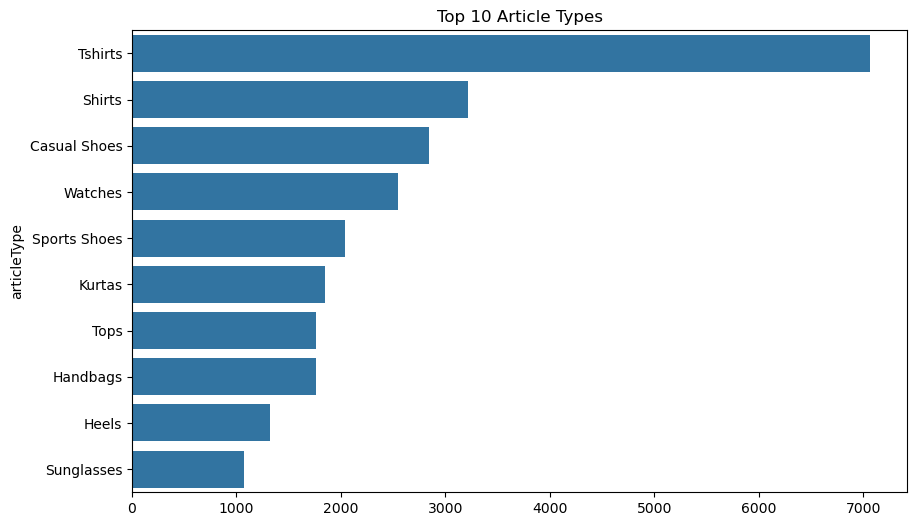

In [6]:
# Top Article Types
top_articles = df['articleType'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_articles.values,
    y=top_articles.index
)

plt.title("Top 10 Article Types")

plt.show()

## 8. Season Distribution

The seasonal distribution of products is analyzed.

This provides insights into how fashion products are distributed across different seasons such as summer, winter, fall, and spring.

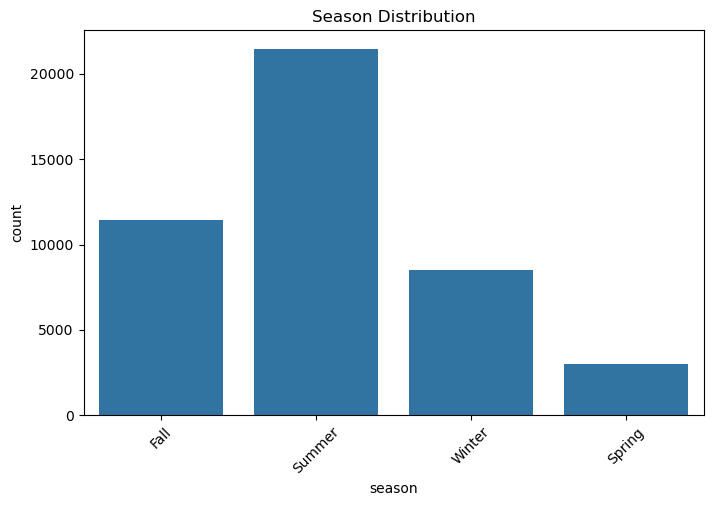

In [7]:
# Season Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='season')

plt.title("Season Distribution")

plt.xticks(rotation=45)

plt.show()

## 9. Usage Distribution

The usage categories describe the purpose or context of fashion products.

Examples include casual wear, sportswear, formal wear, and travel-related products.

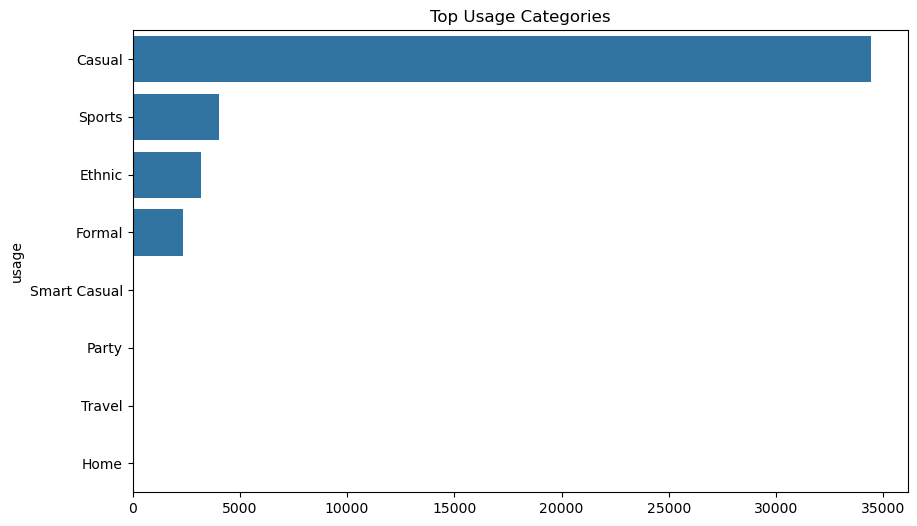

In [8]:
# Usage Distribution
top_usage = df['usage'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_usage.values,
    y=top_usage.index
)

plt.title("Top Usage Categories")

plt.show()

## 10. Image Directory Configuration

The image directory is connected to the project.

Each product image is associated with a unique product ID from the dataset. These images will later be processed by the CNN model.

In [9]:
# SECTION 9 - Image Path

image_path = r"C:\Study\Artificial Intelligence\Rocommendation Algorithm\images"

print("Image Folder Connected Successfully")

Image Folder Connected Successfully


## 11. Image Verification

A sample image path is tested to verify that the product images correctly correspond to product IDs in the dataset.

Successful verification confirms that the image dataset is properly linked with the metadata.

In [10]:
# SECTION 10 - Verify Image Files
sample_id = df['id'].iloc[0]

sample_image = os.path.join(image_path, f"{sample_id}.jpg")

print("Sample Image Path:")
print(sample_image)

print("\nImage Exists:")
print(os.path.exists(sample_image))

Sample Image Path:
C:\Study\Artificial Intelligence\Rocommendation Algorithm\images\15970.jpg

Image Exists:
True


## 12. Displaying a Sample Product Image

A sample fashion image is loaded and displayed.

This confirms that the image files can be successfully accessed and visualized before CNN preprocessing.

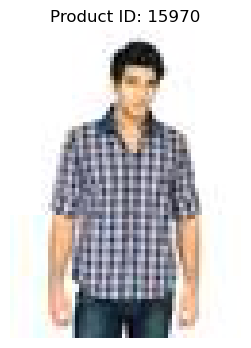

In [11]:
# Load One Sample Image
img = Image.open(sample_image)

plt.figure(figsize=(4,4))

plt.imshow(img)

plt.title(f"Product ID: {sample_id}")

plt.axis('off')

plt.show()

## 13. Image Resizing

The image is resized to 224 × 224 pixels.

This image size is required for CNN architectures such as ResNet50 and ensures consistent input dimensions during feature extraction.

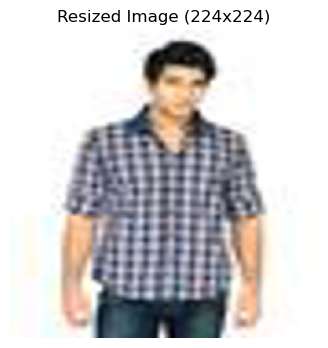

In [12]:
# SECTION 12 - Image Resizing
img_resized = img.resize((224, 224))

plt.figure(figsize=(4,4))

plt.imshow(img_resized)

plt.title("Resized Image (224x224)")

plt.axis('off')

plt.show()

## 14. Image Conversion to Numerical Array

The resized image is converted into a NumPy array.

CNN models process images as numerical tensors, where pixel intensities are represented as numerical values.

In [13]:
# onvert Image to Array

img_array = np.array(img_resized)

print("Image Shape:")
print(img_array.shape)

Image Shape:
(224, 224, 3)


height × width × channels

## 15. Displaying Multiple Fashion Products
Several fashion product images are displayed to visually inspect the diversity of the dataset.

The dataset includes different clothing categories, colours, and fashion styles.

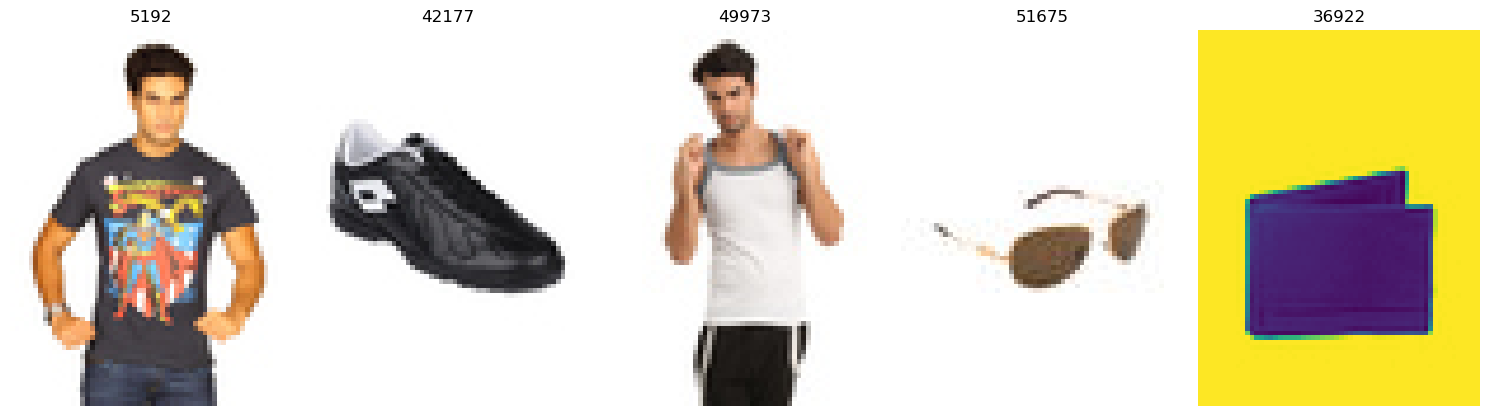

In [14]:
# Display Multiple Fashion Images
sample_ids = df['id'].sample(5)

plt.figure(figsize=(15,5))

for i, img_id in enumerate(sample_ids):

    img_file = os.path.join(image_path, f"{img_id}.jpg")

    if os.path.exists(img_file):

        img = Image.open(img_file)

        plt.subplot(1,5,i+1)

        plt.imshow(img)

        plt.title(str(img_id))

        plt.axis('off')

plt.tight_layout()

plt.show()

## 16. Importing CNN Libraries

TensorFlow and Keras libraries are imported for deep learning image processing.

The pre-trained ResNet50 model is used for CNN feature extraction from fashion product images.

In [15]:
# SECTION 15 - Import CNN Libraries
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import Model

print("TensorFlow and ResNet50 Loaded Successfully")

TensorFlow and ResNet50 Loaded Successfully


## 17. Loading the ResNet50 Model

The pre-trained ResNet50 CNN architecture is loaded using ImageNet weights.

The classification layer is removed because the model is used for feature extraction rather than image classification.

Global average pooling is applied to obtain compact image feature vectors.

In [16]:
# SECTION 16 - Load ResNet50 Model

model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

print("ResNet50 Model Loaded Successfully")

ResNet50 Model Loaded Successfully


## 18. Image Preprocessing for CNN

The fashion image is resized and converted into a numerical tensor.

Additional preprocessing steps are applied to match the input requirements of the ResNet50 architecture.

In [17]:
#  Image Preprocessing for CNN
img_path = sample_image

img = image.load_img(
    img_path,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

print("Image Preprocessing Completed")

print(img_array.shape)

Image Preprocessing Completed
(1, 224, 224, 3)


(batch_size, height, width, channels)

## 19. CNN Feature Extraction

The ResNet50 model extracts high-level image features from the fashion product image.

The resulting feature vector represents visual characteristics such as shape, colour, texture, and style.

In [18]:
#  CNN Feature Extraction
features = model.predict(img_array)

print("Feature Extraction Completed")

print("Feature Vector Shape:")
print(features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Feature Extraction Completed
Feature Vector Shape:
(1, 2048)


## 20. Similarity Measurement

Cosine similarity is used to measure similarity between image feature vectors.

Products with similar CNN feature representations are considered visually similar fashion items.

In [19]:
# Import Similarity Function

from sklearn.metrics.pairwise import cosine_similarity

print("Cosine Similarity Imported Successfully")

Cosine Similarity Imported Successfully


## 21. Feature Extraction Function

A reusable feature extraction function is created.

The function preprocesses fashion images and extracts CNN feature vectors using the ResNet50 model.

In [20]:

# SECTION 20 - Feature Extraction Function

def extract_features(img_path, model):

    img = image.load_img(
        img_path,
        target_size=(224, 224)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    features = model.predict(img_array, verbose=0)

    return features.flatten()  #(2048,)

## 22. Feature Extraction from Multiple Fashion Images

CNN feature vectors are extracted from multiple fashion product images.

These feature vectors form the basis of the recommendation system.

In [21]:
# Extract Features from Dataset

image_features = []

image_ids = []

sample_df = df.head(100)

for product_id in sample_df['id']:

    img_file = os.path.join(
        image_path,
        f"{product_id}.jpg"
    )

    if os.path.exists(img_file):

        try:

            features = extract_features(
                img_file,
                model
            )

            image_features.append(features)

            image_ids.append(product_id)

        except:

            pass

print("Feature Extraction for Dataset Completed")

print("Number of Feature Vectors:")
print(len(image_features))

Feature Extraction for Dataset Completed
Number of Feature Vectors:
100


## 23. Query Image Selection

A fashion product image is selected as the query image for recommendation generation.

In [22]:
# Query Image Selection

query_index = 0

query_features = image_features[query_index]

print("Query Image Selected")

Query Image Selected


## 24. Similarity Computation

Cosine similarity scores are calculated between the query image and all extracted feature vectors.

Higher similarity scores indicate visually similar fashion products.

In [23]:
# Similarity Calculation

similarity_scores = cosine_similarity(
    [query_features],
    image_features
)

print("Similarity Calculation Completed")

print(similarity_scores.shape)

Similarity Calculation Completed
(1, 100)


## 25. Finding Similar Fashion Products

The most visually similar products are identified based on cosine similarity scores.

The recommendation system retrieves the nearest fashion items in feature space.

In [24]:
#  Find Similar Products

similar_indices = similarity_scores[0].argsort()[-6:-1][::-1]

print("Top Similar Product Indices:")

print(similar_indices)

Top Similar Product Indices:
[44  6 30 90  4]


## 26. Fashion Recommendation Results

The recommendation system displays visually similar fashion products based on CNN feature similarity.

The retrieved products often share similar colours, styles, textures, or clothing categories with the query image.

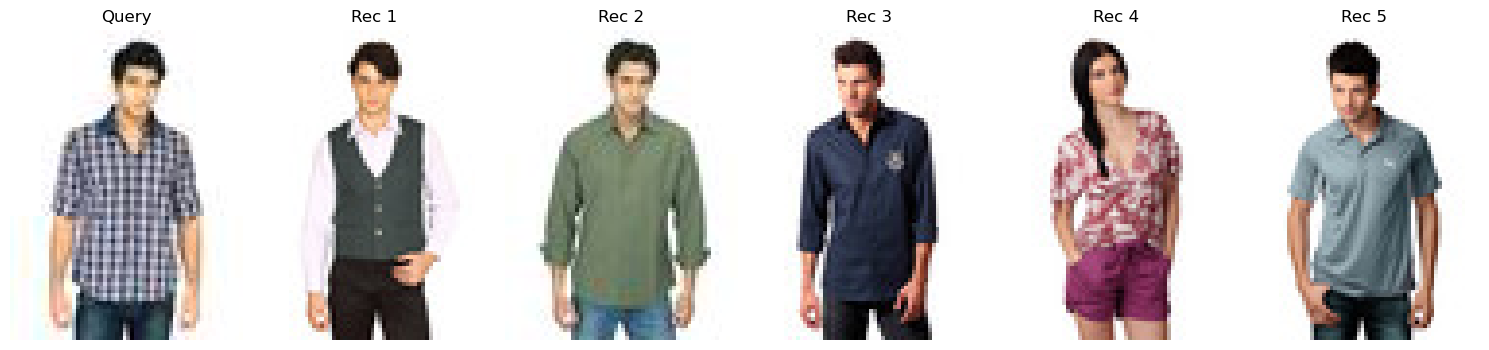

In [25]:
# Display Recommendations

plt.figure(figsize=(15,8))

# Query Image
query_id = image_ids[query_index]

query_img = Image.open(
    os.path.join(image_path, f"{query_id}.jpg")
)

plt.subplot(1,6,1)

plt.imshow(query_img)

plt.title("Query")

plt.axis('off')

# Recommended Images
for i, idx in enumerate(similar_indices):

    rec_id = image_ids[idx]

    rec_img = Image.open(
        os.path.join(image_path, f"{rec_id}.jpg")
    )

    plt.subplot(1,6,i+2)

    plt.imshow(rec_img)

    plt.title(f"Rec {i+1}")

    plt.axis('off')

plt.tight_layout()

plt.show()

## 27. CNN Classification Dataset

A smaller labeled dataset is created for CNN classification experiments.

The master product category is used as the target variable for image classification.

In [26]:
#Create Classification Dataset
classification_df = df[
    df['masterCategory'].notnull()
]

classification_df = classification_df.head(1000)

print(classification_df['masterCategory'].value_counts())

masterCategory
Apparel          454
Accessories      265
Footwear         220
Personal Care     58
Free Items         3
Name: count, dtype: int64


## 28. Label Encoding

Text-based category labels are converted into numerical labels for CNN classification.

In [27]:
#  Label Encoding

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

classification_df['label'] = label_encoder.fit_transform(
    classification_df['masterCategory']
)

print(classification_df[['masterCategory', 'label']].head())

  masterCategory  label
0        Apparel      1
1        Apparel      1
2    Accessories      0
3        Apparel      1
4        Apparel      1


## 29. Image Loading for CNN Training

Fashion images are resized and normalized before CNN training.

Pixel values are scaled between 0 and 1 to improve neural network training stability.

In [28]:
# Load Images and Labels

X = []
y = []

for _, row in classification_df.iterrows():

    img_file = os.path.join(
        image_path,
        f"{row['id']}.jpg"
    )

    if os.path.exists(img_file):

        try:

            img = image.load_img(
                img_file,
                target_size=(128, 128)
            )

            img_array = image.img_to_array(img)

            img_array = img_array / 255.0

            X.append(img_array)

            y.append(row['label'])

        except:

            pass

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1000, 128, 128, 3)
(1000,)


## 30. Train-Test Split

The dataset is divided into training and testing subsets.

The training data is used for CNN learning, while the testing data is used for evaluation.

In [29]:
#  Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 128, 128, 3)
(200, 128, 128, 3)


## 31. CNN Model with Dropout

A CNN architecture with dropout regularization is created.

Dropout helps reduce overfitting by randomly disabling neurons during training.

In [30]:
#  CNN Model with Dropout

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

num_classes = len(np.unique(y))

model_dropout = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model with Dropout Created")

CNN Model with Dropout Created


C:\Users\garli\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 32. CNN Training

The CNN model is trained on fashion product images.

Training and validation accuracy are monitored across multiple epochs.

In [31]:
# Train CNN Model
history_dropout = model_dropout.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=5,

    batch_size=32
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5437 - loss: 1.5780 - val_accuracy: 0.7650 - val_loss: 0.5313
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8413 - loss: 0.4250 - val_accuracy: 0.8900 - val_loss: 0.2845
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9275 - loss: 0.2536 - val_accuracy: 0.9250 - val_loss: 0.2408
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9513 - loss: 0.1885 - val_accuracy: 0.9300 - val_loss: 0.2251
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9575 - loss: 0.1416 - val_accuracy: 0.8800 - val_loss: 0.3197


## 33. CNN Evaluation

The CNN classification model is evaluated using the testing dataset.

Classification accuracy is used as the primary evaluation metric.

In [32]:
#  Model Evaluation

test_loss, test_accuracy = model_dropout.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:")
print(test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8800 - loss: 0.3197
Test Accuracy:
0.8799999952316284


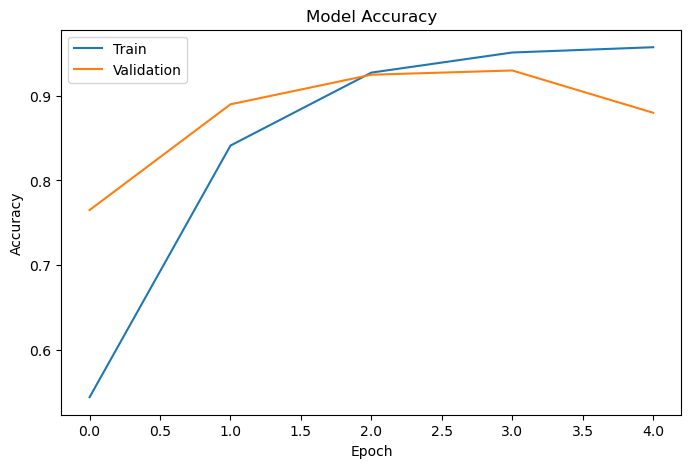

In [33]:
#  Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(history_dropout.history['accuracy'])

plt.plot(history_dropout.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

The CNN model achieved high training accuracy and strong validation accuracy on the fashion classification task.

The validation accuracy improved rapidly during the early epochs, indicating that the CNN successfully learned visual fashion features.

However, after approximately the third epoch, validation accuracy slightly decreased while training accuracy continued increasing. This suggests mild overfitting, even with dropout regularization applied.

## 34. Training Curves

Training and validation curves are visualized to analyze CNN learning behavior and potential overfitting.

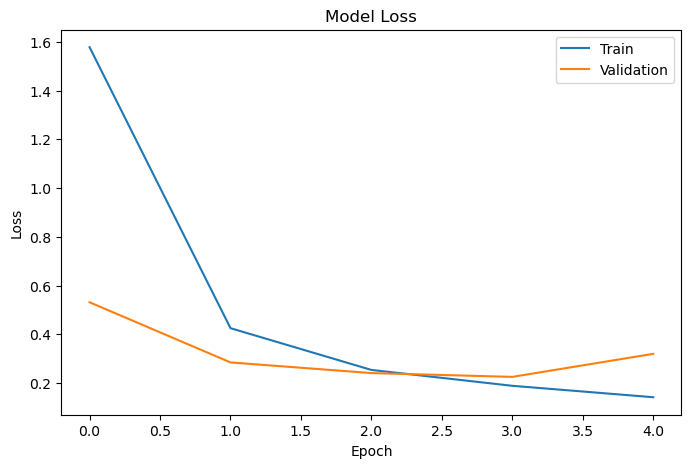

In [34]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(history_dropout.history['loss'])

plt.plot(history_dropout.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

## 35. CNN Model without Dropout

A second CNN model is created without dropout regularization.

This experiment is designed to compare model performance and overfitting behavior.

In [35]:
# CNN WITHOUT Dropout

model_no_dropout = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model_no_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model WITHOUT Dropout Created")

CNN Model WITHOUT Dropout Created


C:\Users\garli\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
#  Train CNN WITHOUT Dropout

history_no_dropout = model_no_dropout.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=5,

    batch_size=32
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6600 - loss: 1.3097 - val_accuracy: 0.8800 - val_loss: 0.3164
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9087 - loss: 0.2790 - val_accuracy: 0.9050 - val_loss: 0.2500
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9538 - loss: 0.1733 - val_accuracy: 0.8550 - val_loss: 0.3601
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9600 - loss: 0.1331 - val_accuracy: 0.9250 - val_loss: 0.2409
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9825 - loss: 0.0675 - val_accuracy: 0.9200 - val_loss: 0.2309


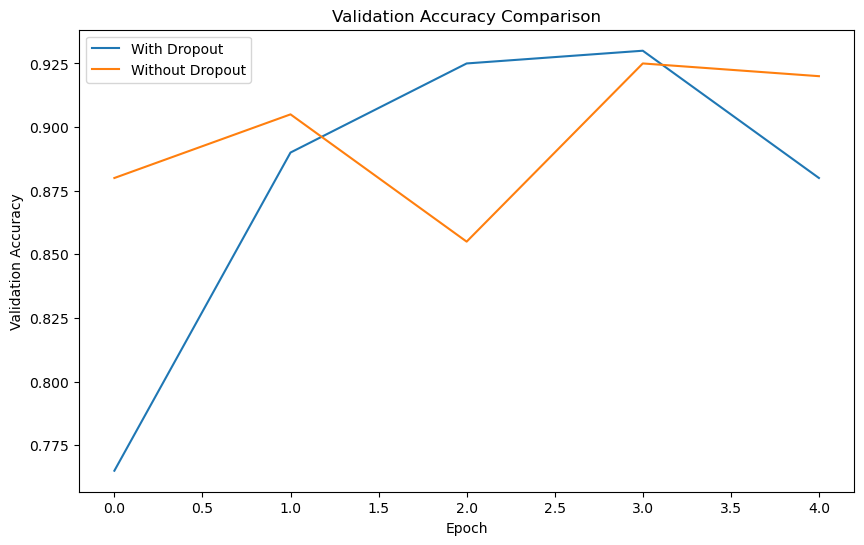

In [37]:
# Compare Dropout vs No Dropout

plt.figure(figsize=(10,6))

# WITH dropout
plt.plot(
    history_dropout.history['val_accuracy'],
    label='With Dropout'
)

# WITHOUT dropout
plt.plot(
    history_no_dropout.history['val_accuracy'],
    label='Without Dropout'
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.legend()

plt.show()

## 36. Dropout Comparison

The CNN model without dropout achieved slightly higher validation accuracy compared to the model with dropout regularization.

This suggests that the dataset size and model complexity were not large enough to cause severe overfitting during the short training process.

Although dropout is generally useful for reducing overfitting, its effect may become more significant in deeper networks or longer training sessions.

## 37. CNN Model using SGD Optimizer

A CNN model is trained using the Stochastic Gradient Descent (SGD) optimizer.

The experiment compares SGD with the Adam optimizer used previously.

In [38]:
# CNN with SGD Optimizer

model_sgd = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model_sgd.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model with SGD Created")

CNN Model with SGD Created


C:\Users\garli\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
# Train CNN with SGD

history_sgd = model_sgd.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=5,

    batch_size=32
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.4200 - loss: 1.3125 - val_accuracy: 0.4650 - val_loss: 1.2343
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5100 - loss: 1.1644 - val_accuracy: 0.7600 - val_loss: 1.0960
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6150 - loss: 1.0270 - val_accuracy: 0.7200 - val_loss: 0.9169
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6200 - loss: 0.9665 - val_accuracy: 0.6400 - val_loss: 0.8765
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6700 - loss: 0.8724 - val_accuracy: 0.8150 - val_loss: 0.6802


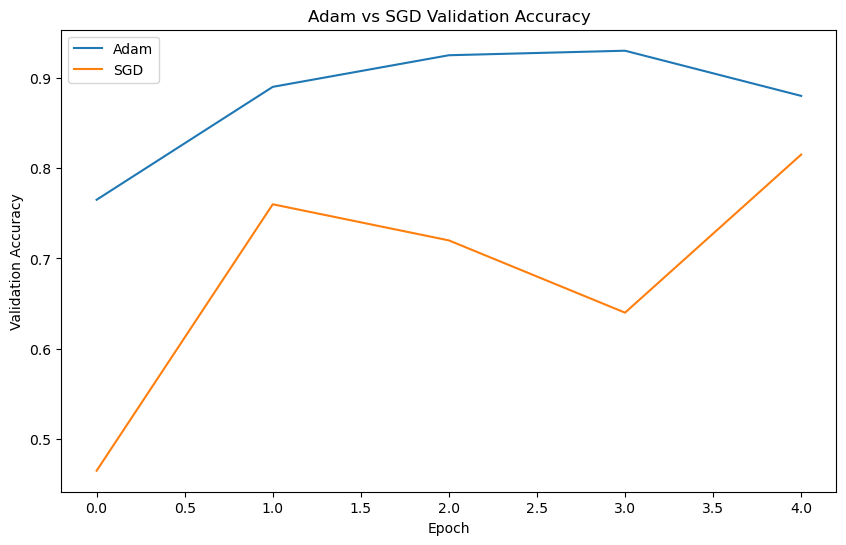

In [40]:
# Optimizer Comparison

plt.figure(figsize=(10,6))

# Adam
plt.plot(
    history_dropout.history['val_accuracy'],
    label='Adam'
)

# SGD
plt.plot(
    history_sgd.history['val_accuracy'],
    label='SGD'
)

plt.title("Adam vs SGD Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.legend()

plt.show()

The Adam optimizer achieved significantly higher validation accuracy compared to SGD.

Adam converged much faster during the early epochs and produced more stable learning behavior throughout the training process.

In contrast, SGD required more epochs to improve performance and showed slower convergence on the fashion image classification task.

## 39. Experimental Comparison Summary

The CNN experiments are summarized by comparing different regularization methods and optimization algorithms.

Validation accuracy is used to evaluate model performance across experiments.

In [41]:
# Experimental Comparison Table
experiment_results = pd.DataFrame({

    'Experiment': [
        'With Dropout',
        'Without Dropout',
        'Adam Optimizer',
        'SGD Optimizer'
    ],

    'Validation Accuracy': [
        max(history_dropout.history['val_accuracy']),
        max(history_no_dropout.history['val_accuracy']),
        max(history_dropout.history['val_accuracy']),
        max(history_sgd.history['val_accuracy'])
    ]
})

print(experiment_results)

        Experiment  Validation Accuracy
0     With Dropout                0.930
1  Without Dropout                0.925
2   Adam Optimizer                0.930
3    SGD Optimizer                0.815


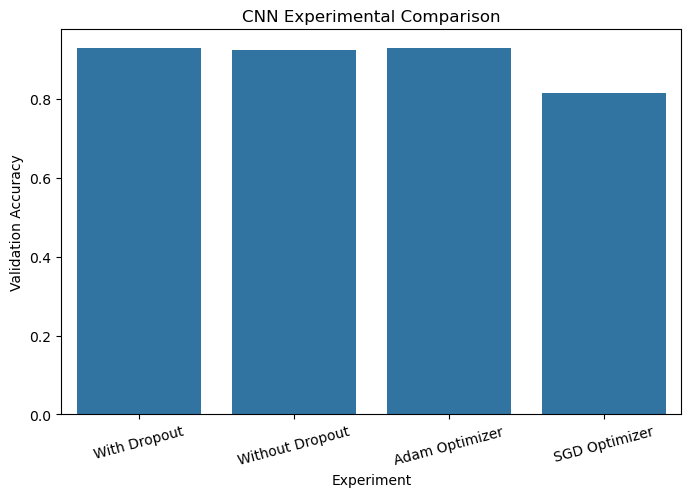

In [42]:
# Final Experiment Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=experiment_results,
    x='Experiment',
    y='Validation Accuracy'
)

plt.title("CNN Experimental Comparison")

plt.xticks(rotation=15)

plt.show()

The CNN-based fashion recommendation project successfully demonstrated both image feature extraction and CNN classification capabilities.

Experimental results showed that the Adam optimizer achieved faster convergence and higher validation accuracy than SGD.

Dropout regularization slightly reduced validation accuracy in this experiment, likely because the dataset size and CNN complexity were relatively small.

The validation accuracy curves also suggested that excessive training epochs may lead to mild overfitting.